<a href="https://colab.research.google.com/github/sarmuh/Bank-Customer-Churn-ML/blob/main/CUSTOMER_CHURN_P1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from matplotlib import pyplot as plt

import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import roc_curve,auc,RocCurveDisplay
from sklearn.metrics import accuracy_score,classification_report,recall_score,precision_score,f1_score,confusion_matrix


In [2]:
url = "https://raw.githubusercontent.com/alishermutalov/praktikum-datasets/refs/heads/praktikum/Churn_Modelling.xls"
df = pd.read_csv(url, index_col='RowNumber')
df

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,,,,,,,,,,,,,
1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 1 to 10000
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  object 
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  object 
 4   Gender           10000 non-null  object 
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1.1+ MB


In [4]:
df.describe().iloc[:,1:-1]

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000


In [5]:
df.isna().sum()

,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0


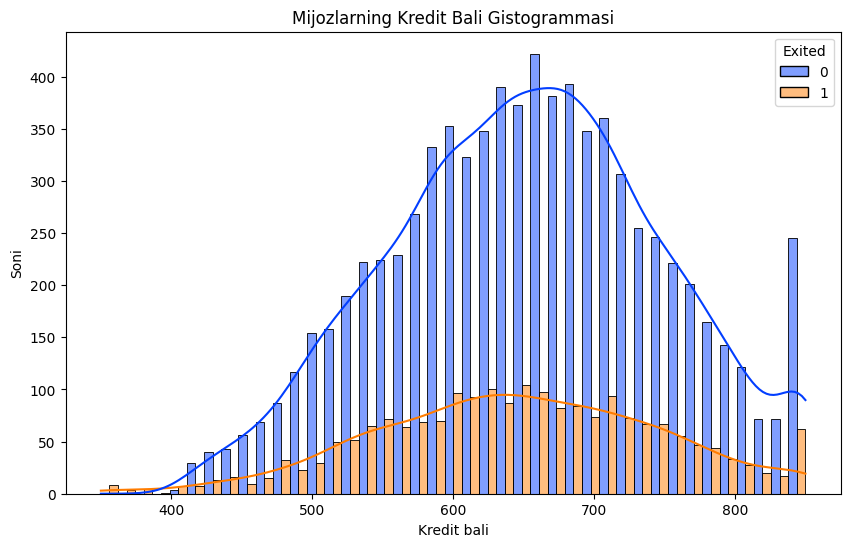

In [6]:
plt.figure(figsize=(10,6))

sns.histplot(data=df,x='CreditScore',hue='Exited',palette='bright',multiple='dodge',kde=True)

plt.title('Mijozlarning Kredit Bali Gistogrammasi')
plt.ylabel('Soni')
plt.xlabel('Kredit bali')
plt.show()

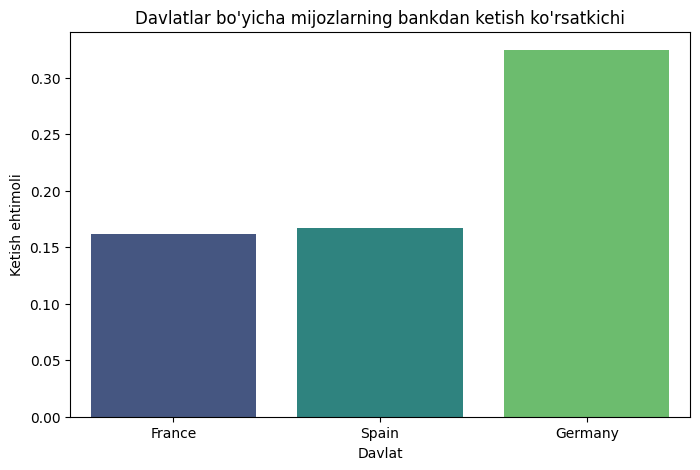

In [7]:
plt.figure(figsize=(8, 5))

sns.barplot(x='Geography', y='Exited', data=df, errorbar=None, palette='viridis',hue='Geography',legend=False)

plt.title("Davlatlar bo'yicha mijozlarning bankdan ketish ko'rsatkichi")
plt.xlabel("Davlat")
plt.ylabel("Ketish ehtimoli")

plt.show()

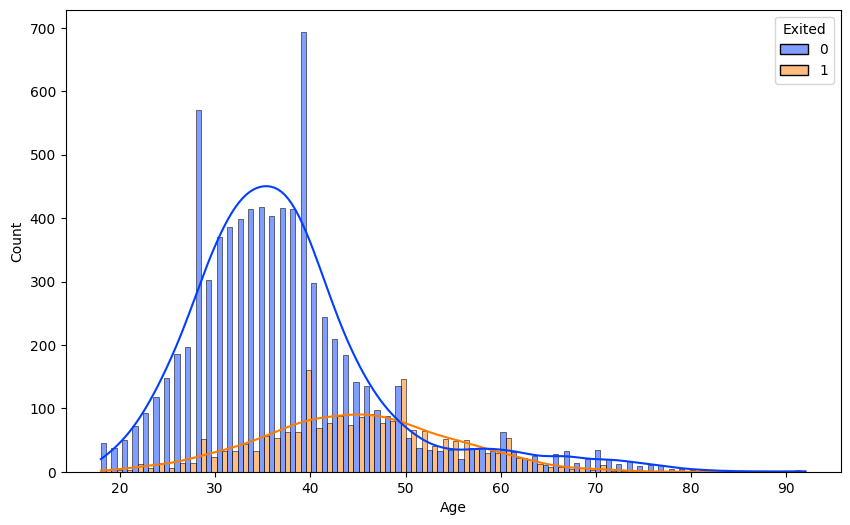

In [8]:
plt.figure(figsize=(10,6))

sns.histplot(data=df,x='Age',hue='Exited',palette='bright',multiple='dodge',kde=True)


plt.show()

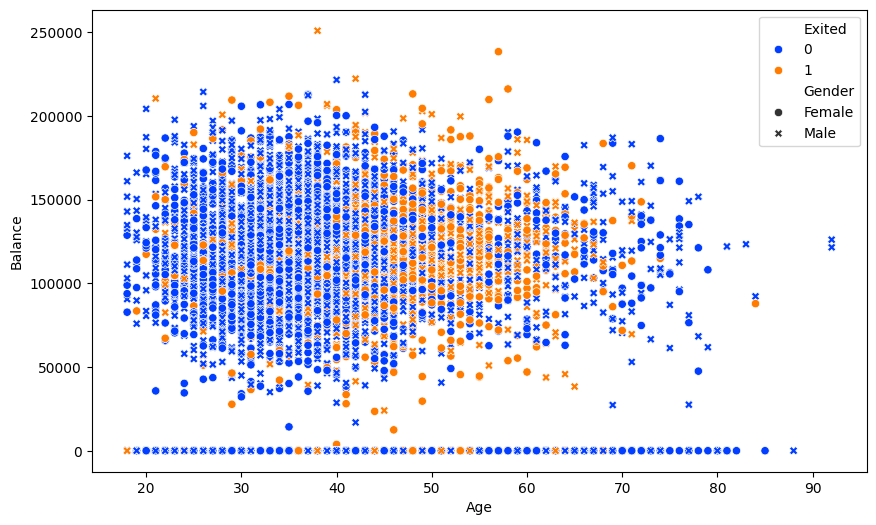

In [9]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df,x='Age',y='Balance', hue='Exited',palette='bright',style='Gender')


plt.show()

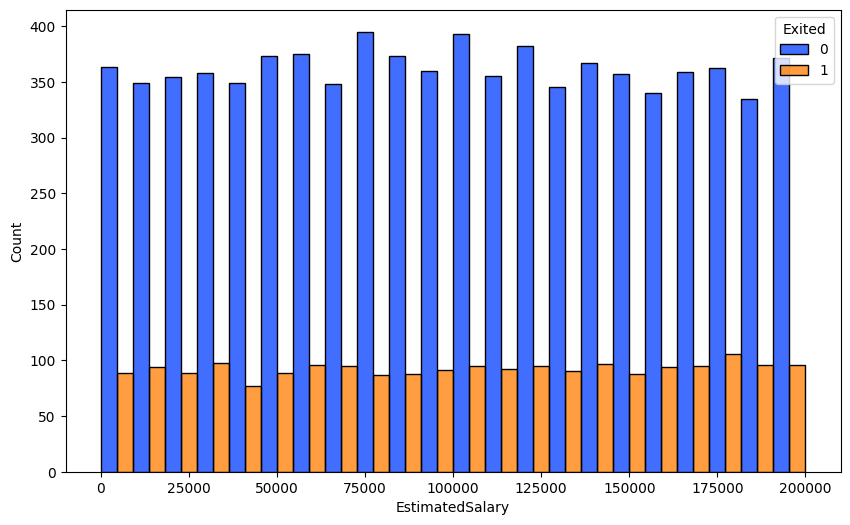

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(data=df,x='EstimatedSalary',hue='Exited',palette='bright',multiple='dodge')

plt.show()

In [11]:
df.drop(['CustomerId','Surname'],axis=1,inplace=True)

In [12]:
df = pd.get_dummies(df,columns=['Geography'],dtype='int')
df.sample(7)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
RowNumber,,,,,,,,,,,,,
2480,652,Female,40,8,84390.80,2,0,1,107876.20,0,1,0,0
4690,771,Male,45,0,139825.56,1,0,0,170984.97,1,0,0,1
1902,796,Male,67,5,0.00,2,0,1,54871.02,0,0,0,1
8318,666,Female,27,4,0.00,2,0,0,88751.45,0,1,0,0
7277,594,Male,35,2,133853.27,1,1,1,65361.66,0,1,0,0
5829,709,Female,37,8,0.00,3,1,0,71738.56,0,0,0,1
4435,633,Female,46,3,0.00,2,1,0,120250.58,0,0,0,1


In [13]:
df['Gender'] = df['Gender'].map({'Male' : 1,'Female':0})
df.sample(5)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
RowNumber,,,,,,,,,,,,,
9021,718,1,34,5,113922.44,2,1,0,30772.22,0,0,0,1
4289,577,0,31,4,61211.18,1,1,1,145250.43,0,0,1,0
9837,587,1,39,10,0.00,2,1,1,170409.45,0,1,0,0
8187,606,0,39,3,0.00,2,1,0,50560.45,1,1,0,0
1263,665,0,40,1,173432.55,1,0,1,116766.79,0,0,0,1


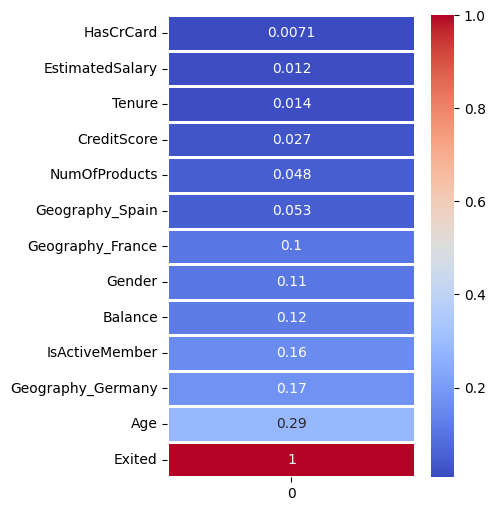

In [14]:
plt.figure(figsize=(4,6))
sns.heatmap((abs(df.corrwith(df['Exited'])).sort_values().to_frame()),annot=True,linewidths=1,cmap='coolwarm')
plt.show()

In [15]:
X = df.drop('Exited',axis=1)
y = df['Exited']
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=49,train_size=0.8)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((8000, 12), (2000, 12), (8000,), (2000,))

In [16]:
scaler = StandardScaler()
X_train_pro = scaler.fit_transform(X_train)
X_test_pro = scaler.transform(X_test)

F1 score 0.5194585448392555
              precision    recall  f1-score   support

           0       0.89      0.72      0.80      1556
           1       0.42      0.69      0.52       444

    accuracy                           0.72      2000
   macro avg       0.65      0.71      0.66      2000
weighted avg       0.79      0.72      0.74      2000



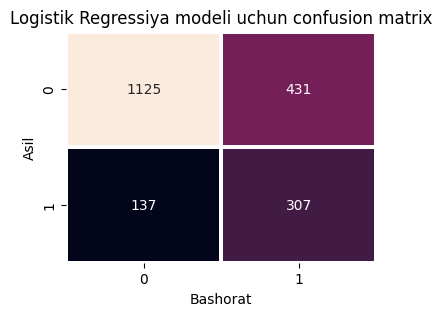

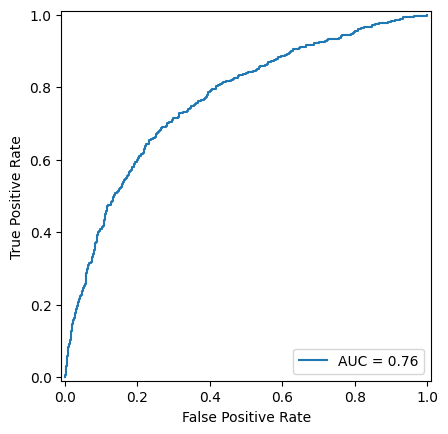

In [17]:
model_LR = LogisticRegression(max_iter=500,class_weight='balanced',n_jobs=-1)
model_LR.fit(X_train_pro,y_train)
y_pred_LR = model_LR.predict(X_test_pro)
print(f'F1 score {f1_score(y_test,y_pred_LR)}')
print(classification_report(y_test,y_pred_LR))

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test,y_pred_LR),annot=True,linewidths=1.5,fmt='d',cbar=False)
plt.title("Logistik Regressiya modeli uchun confusion matrix")
plt.ylabel('Asil')
plt.xlabel('Bashorat')
plt.show()


proba_LR = model_LR.predict_proba(X_test_pro)[:,1]
fpr, tpr, threshold = roc_curve(y_test,proba_LR)
roc_auc = auc(fpr,tpr)
RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc).plot()
plt.show()

F1 score 0.6310772163965681
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1556
           1       0.55      0.75      0.63       444

    accuracy                           0.81      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84      0.81      0.82      2000



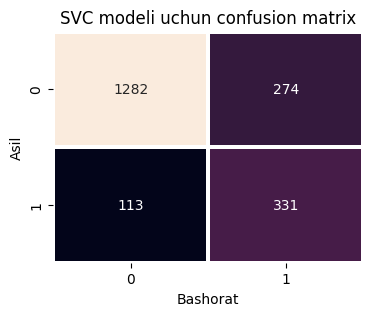

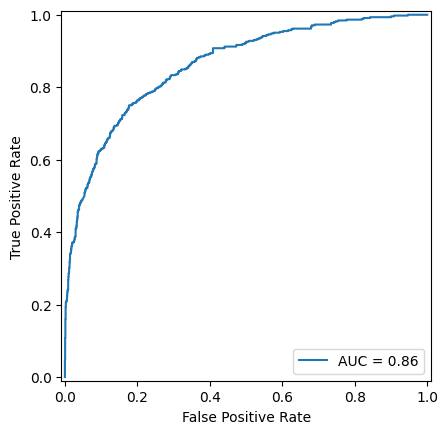

In [18]:
model_SVC = SVC(class_weight='balanced',probability=True)
model_SVC.fit(X_train_pro,y_train)
y_pred_SVC = model_SVC.predict(X_test_pro)
print(f'F1 score {f1_score(y_test,y_pred_SVC)}')
print(classification_report(y_test,y_pred_SVC))

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test,y_pred_SVC),annot=True,linewidths=1.5,fmt='d',cbar=False)
plt.title("SVC modeli uchun confusion matrix")
plt.ylabel('Asil')
plt.xlabel('Bashorat')
plt.show()


proba_SVC = model_SVC.predict_proba(X_test_pro)[:,1]
fpr, tpr, threshold = roc_curve(y_test,proba_SVC)
roc_auc = auc(fpr,tpr)
RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc).plot()
plt.show()

F1 score 0.6310772163965681
              precision    recall  f1-score   support

           0       0.92      0.82      0.87      1556
           1       0.55      0.75      0.63       444

    accuracy                           0.81      2000
   macro avg       0.73      0.78      0.75      2000
weighted avg       0.84      0.81      0.82      2000



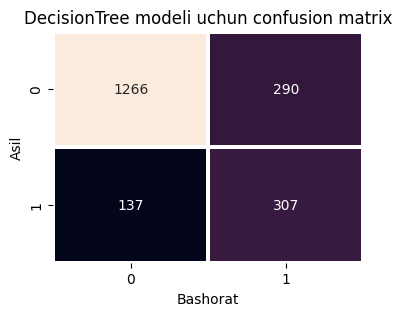

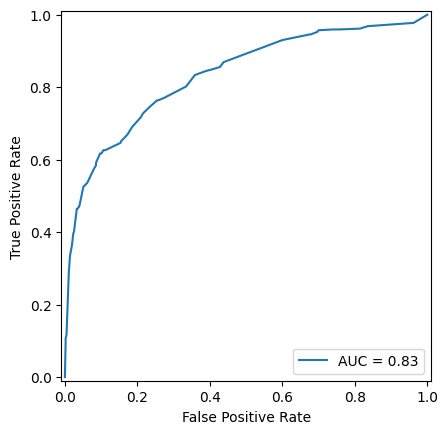

In [19]:
model_DT = DecisionTreeClassifier(class_weight='balanced',max_depth=7)
model_DT.fit(X_train_pro,y_train)
y_pred_DT = model_DT.predict(X_test_pro)
print(f'F1 score {f1_score(y_test,y_pred_SVC)}')
print(classification_report(y_test,y_pred_SVC))

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_test,y_pred_DT),annot=True,linewidths=1.5,fmt='d',cbar=False)
plt.title("DecisionTree modeli uchun confusion matrix")
plt.ylabel('Asil')
plt.xlabel('Bashorat')
plt.show()


proba_DT = model_DT.predict_proba(X_test_pro)[:,1]
fpr, tpr, threshold = roc_curve(y_test,proba_DT)
roc_auc = auc(fpr,tpr)
RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc).plot()
plt.show()

F1 score 0.636986301369863
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      1556
           1       0.65      0.63      0.64       444

    accuracy                           0.84      2000
   macro avg       0.77      0.77      0.77      2000
weighted avg       0.84      0.84      0.84      2000



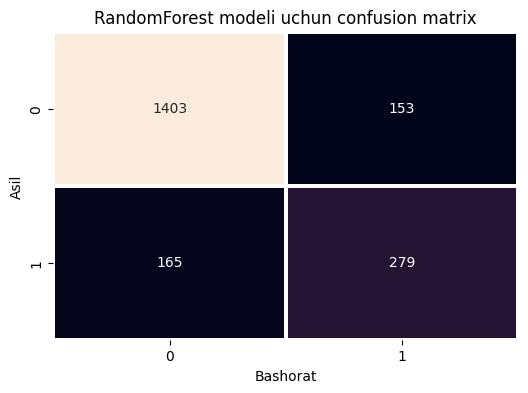

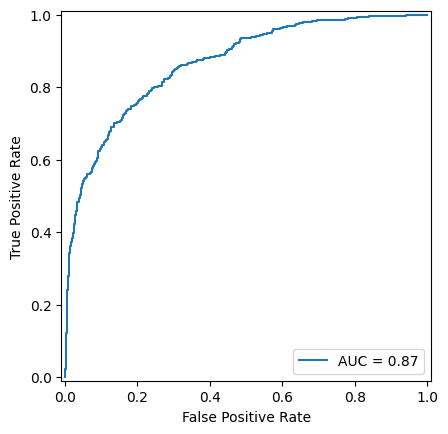

In [20]:
model_RF = RandomForestClassifier(n_estimators=500,class_weight='balanced',max_depth=10)
model_RF.fit(X_train_pro,y_train)
y_pred_RF = model_RF.predict(X_test_pro)
print(f"F1 score {f1_score(y_test,y_pred_RF)}")
print(classification_report(y_test,y_pred_RF))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test,y_pred_RF),annot=True,fmt='d',linewidths=1.5,cbar=False)
plt.title('RandomForest modeli uchun confusion matrix')
plt.xlabel('Bashorat')
plt.ylabel('Asil')
plt.show()

proba_RF = model_RF.predict_proba(X_test_pro)[:,1]
fpr,tpr,threshold = roc_curve(y_test,proba_RF)
roc_auc = auc(fpr,tpr)
RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc).plot()
plt.show()

F1 score 0.5860349127182045
              precision    recall  f1-score   support

           0       0.87      0.92      0.90      1556
           1       0.66      0.53      0.59       444

    accuracy                           0.83      2000
   macro avg       0.76      0.73      0.74      2000
weighted avg       0.82      0.83      0.83      2000



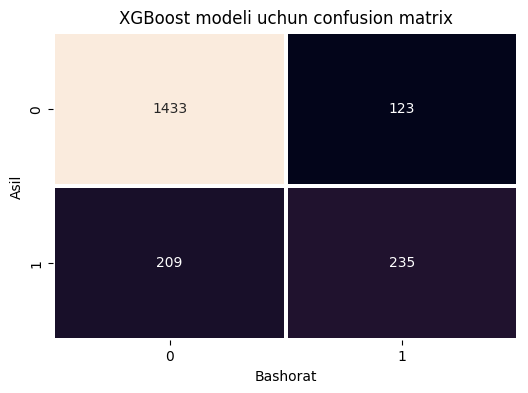

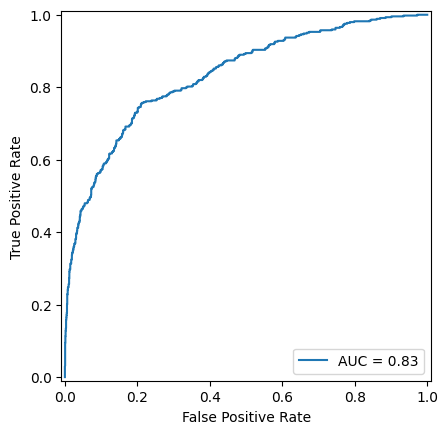

In [21]:
model_XG = XGBClassifier(n_estimators=500,max_depth=10,scale_pos_weight=4)
model_XG.fit(X_train_pro,y_train)
y_pred_XG = model_XG.predict(X_test_pro)
print(f"F1 score {f1_score(y_test,y_pred_XG)}")
print(classification_report(y_test,y_pred_XG))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test,y_pred_XG),annot=True,fmt='d',linewidths=1.5,cbar=False)
plt.title('XGBoost modeli uchun confusion matrix')
plt.xlabel('Bashorat')
plt.ylabel('Asil')
plt.show()

proba_XG = model_XG.predict_proba(X_test_pro)[:,1]
fpr,tpr,threshold = roc_curve(y_test,proba_XG)
roc_auc = auc(fpr,tpr)
RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc).plot()
plt.show()

# **Train natijalari pastligi sababli yana 2 xil turda qayta train o'tkazamiz**


1.   ***SMOTE** orqali datasetni qayta to'ldirib train qilamiz*
2.   *Oversampling*

